# Laboratorio 30 (Práctica 31) - Conexión y captura de video desde cámara

Visión Computacional - CUC

Lo corrí en mi portátil (Windows 11, Python 3.12, OpenCV 5.0) con la webcam integrada.

Cosas a tener en cuenta para que funcione:
- cerrar Zoom / Teams / Meet antes, si otro programa tiene la cámara no abre
- usar `opencv-python` normal, la headless no abre ventanas
- cuando se abre la ventana hay que darle **clic** para que reciba las teclas. Igual cada ciclo tiene un límite de tiempo por si acaso

## Configuración y funciones de apoyo

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time
import os
import json
import platform
import glob

os.makedirs('resultados', exist_ok=True)

INDICE_CAMARA = 0
LIMITE_SEG = 20      # corte automático de cada ciclo, por si la ventana no agarra el teclado

# revisar que OpenCV sí pueda abrir ventanas (con la versión headless no se puede)
try:
    cv2.namedWindow('prueba')
    cv2.destroyWindow('prueba')
    cv2.waitKey(1)
    HAY_GUI = True
except cv2.error:
    HAY_GUI = False

# aquí voy guardando todo lo que mido para después armar el informe
datos = {}
def registrar(clave, valor):
    datos[clave] = valor
    with open('resultados/datos_lab30.json', 'w', encoding='utf-8') as f:
        json.dump(datos, f, indent=2, ensure_ascii=False, default=str)

def abrir_camara(indice=INDICE_CAMARA):
    cap = cv2.VideoCapture(indice)
    if not cap.isOpened():
        raise RuntimeError(f'No abrió la cámara {indice}: revisar permisos o si otro programa la tiene')
    return cap, f'camara {indice}'

def cerrar_ventanas():
    cv2.destroyAllWindows()
    for _ in range(5):
        cv2.waitKey(1)   # a veces las ventanas se quedan pegadas si no se hace esto

def ver(img, titulo='', ancho=8):
    # para mostrar imágenes dentro del notebook
    plt.figure(figsize=(ancho, ancho * 0.6))
    if img.ndim == 2:
        plt.imshow(img, cmap='gray')
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(titulo)
    plt.axis('off')
    plt.show()

backends = [cv2.videoio_registry.getBackendName(b) for b in cv2.videoio_registry.getCameraBackends()]
equipo = {'so': f'{platform.system()} {platform.release()}', 'python': platform.python_version(),
          'opencv': cv2.__version__, 'hay_gui': HAY_GUI, 'backends_camara': backends}
registrar('equipo', equipo)
equipo

{'so': 'Windows 11',
 'python': '3.12.10',
 'opencv': '5.0.0',
 'hay_gui': True,
 'backends_camara': ['GSTREAMER',
  'MSMF',
  'DSHOW',
  'FFMPEG',
  'UEYE',
  'OBSENSOR']}

Los backends son las "librerías" que OpenCV puede usar para hablar con la cámara. En Windows los importantes son MSMF (Media Foundation, el que usa por defecto) y DSHOW (DirectShow).

## 4.1 Conexión básica

Pruebo los índices 0 a 3 para ver cuáles responden.

In [3]:
indices = []
for i in range(4):
    c = cv2.VideoCapture(i)
    abierta = c.isOpened()
    ok, fr = c.read() if abierta else (False, None)
    info = {'indice': i, 'isOpened': abierta, 'read': ok,
            'backend': c.getBackendName() if abierta else None,
            'shape': fr.shape if ok else None}
    c.release()
    indices.append(info)
    print(info)
registrar('4_1_indices', indices)

{'indice': 0, 'isOpened': True, 'read': True, 'backend': 'MSMF', 'shape': (480, 640, 3)}
{'indice': 1, 'isOpened': False, 'read': False, 'backend': None, 'shape': None}
{'indice': 2, 'isOpened': False, 'read': False, 'backend': None, 'shape': None}
{'indice': 3, 'isOpened': False, 'read': False, 'backend': None, 'shape': None}


Solo respondió el índice 0, que es la webcam del portátil, con backend MSMF y frames de 480x640x3. Del 1 al 3 nada porque no tengo otra cámara conectada. Si conectara una USB seguramente quedaría en el 1.

In [4]:
# el de la guía
cap = cv2.VideoCapture(0)
print('isOpened:', cap.isOpened())
fuente = 'camara 0'
print('fuente usada:', fuente)
registrar('fuente', fuente)

isOpened: True
fuente usada: camara 0


## 4.2 Dimensiones del flujo

In [5]:
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print('Ancho:', width)
print('Alto:', height)
print('FPS (propiedad):', cap.get(cv2.CAP_PROP_FPS))
cap.release()

Ancho: 640
Alto: 480
FPS (propiedad): 30.0


640x480 y 30 fps, la resolución por defecto de la webcam.

Para comparar configuraciones le pido a la cámara otras resoluciones con `cap.set` y reviso qué entrega de verdad (miro el tamaño del frame, no solo el `get`).

In [7]:
pruebas = [('por defecto', None), ('pedir 1280x720', (1280, 720)),
           ('pedir 1920x1080', (1920, 1080)), ('pedir 320x240', (320, 240))]
tabla_res = []
for nombre, res in pruebas:
    c, f = abrir_camara()
    set_ok = None
    if res:
        set_ok = [c.set(cv2.CAP_PROP_FRAME_WIDTH, res[0]), c.set(cv2.CAP_PROP_FRAME_HEIGHT, res[1])]
    ok, fr = c.read()
    fila = {'prueba': nombre, 'fuente': f, 'set_devolvio': set_ok,
            'get': [int(c.get(cv2.CAP_PROP_FRAME_WIDTH)), int(c.get(cv2.CAP_PROP_FRAME_HEIGHT))],
            'frame_real': [fr.shape[1], fr.shape[0]] if ok else None}
    c.release()
    tabla_res.append(fila)
    print(fila)
registrar('4_2_resoluciones', tabla_res)

{'prueba': 'por defecto', 'fuente': 'camara 0', 'set_devolvio': None, 'get': [640, 480], 'frame_real': [640, 480]}


error: OpenCV(5.0.0) D:\a\opencv-python\opencv-python\opencv\modules\core\src\matrix.cpp:833: error: (-215:Assertion failed) _step >= minstep in function 'cv::Mat::Mat'


Aquí me salió un error. La configuración por defecto funcionó (640x480), pero al pedirle **1280x720** con `set` se cayó en `cap.read()` con `_step >= minstep in function 'cv::Mat::Mat'`.

Por lo que entiendo, MSMF aceptó el cambio pero el frame que llegó no tenía el tamaño que OpenCV esperaba para armar la matriz, entonces falla. O sea que cambiar la resolución con `set` depende mucho del driver y del backend, no es solo pedirla. Lo que se puede intentar es abrir la cámara con `cv2.VideoCapture(0, cv2.CAP_DSHOW)` o pedir solo resoluciones que la cámara soporte de verdad.

Por eso la tabla de esta parte quedó con dos pruebas: por defecto (funciona) y 1280x720 (error).

## 4.3 Captura en tiempo real (gris)

El script de la guía. Solo le agregué el `if not ret: break` (sin eso, si la cámara falla, `cvtColor` revienta con None, ver abajo) y el límite de tiempo.

**q para salir.**

554 frames en 18.5 s -> 29.9 fps


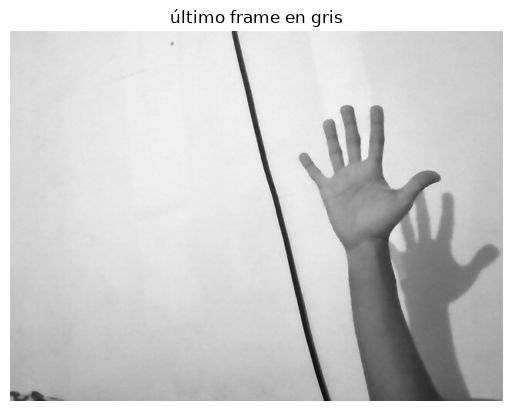

In [9]:
cap, fuente = abrir_camara()

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

n = 0
t0 = time.time()
while True:
    # Captura frame por frame
    ret, frame = cap.read()
    if not ret:
        break

    # Operación sobre el frame
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Mostrar el frame resultante
    cv2.imshow('frame', gray)
    n += 1

    # Presionar q para salir
    if (cv2.waitKey(1) & 0xFF) == ord('q') or time.time() - t0 > LIMITE_SEG:
        break

t = time.time() - t0
cap.release()
cerrar_ventanas()

cv2.imwrite('resultados/4_3_original.jpg', frame)
cv2.imwrite('resultados/4_3_gris.jpg', gray)
print(f'{n} frames en {t:.1f} s -> {n/t:.1f} fps')
registrar('4_3_gris', {'fuente': fuente, 'resolucion': [width, height], 'frames': n,
                       'segundos': round(t, 2), 'fps': round(n / t, 1)})
ver(gray, 'último frame en gris')

Casi 30 fps, que es justo lo que da la cámara. Convertir a gris es tan rápido que no se nota, el que manda es la cámara.

Qué pasa si no se revisa `ret` (read devuelve None cuando falla):

In [10]:
try:
    cv2.cvtColor(None, cv2.COLOR_BGR2GRAY)
except cv2.error as e:
    print('Error:', str(e).strip().splitlines()[-1])

Error: OpenCV(5.0.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'


## 4.4 Otras operaciones sobre cada frame

Corre cada operación unos segundos (o hasta q). Mido los fps que se alcanzan y cuánto tarda solo la operación.

In [11]:
operaciones = {
    'gris': lambda f: cv2.cvtColor(f, cv2.COLOR_BGR2GRAY),
    'gaussiano 9x9': lambda f: cv2.GaussianBlur(f, (9, 9), 0),
    'canny': lambda f: cv2.Canny(cv2.cvtColor(f, cv2.COLOR_BGR2GRAY), 100, 200),
    'invertida': lambda f: cv2.bitwise_not(f),
}
SEG_POR_OP = 6

res_ops = {}
muestras = {}
for nombre, op in operaciones.items():
    cap, fuente = abrir_camara()
    print(f'>> {nombre}  (q para pasar a la siguiente)')
    n, t_op = 0, 0.0
    t0 = time.time()
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        a = time.perf_counter()
        procesado = op(frame)
        t_op += time.perf_counter() - a
        cv2.imshow(nombre, procesado)
        n += 1
        if (cv2.waitKey(1) & 0xFF) == ord('q') or time.time() - t0 > SEG_POR_OP:
            break
    t = time.time() - t0
    cap.release()
    cerrar_ventanas()
    muestras[nombre] = procesado
    cv2.imwrite(f'resultados/4_4_{nombre.split()[0]}.jpg', procesado)
    res_ops[nombre] = {'frames': n, 'fps': round(n / t, 1), 'ms_operacion': round(1000 * t_op / n, 3)}
    print('  ', res_ops[nombre])

registrar('4_4_operaciones', res_ops)

>> gris  (q para pasar a la siguiente)
   {'frames': 173, 'fps': 28.8, 'ms_operacion': 0.301}
>> gaussiano 9x9  (q para pasar a la siguiente)
   {'frames': 183, 'fps': 30.3, 'ms_operacion': 1.159}
>> canny  (q para pasar a la siguiente)
   {'frames': 178, 'fps': 29.3, 'ms_operacion': 1.279}
>> invertida  (q para pasar a la siguiente)
   {'frames': 42, 'fps': 27.9, 'ms_operacion': 0.39}


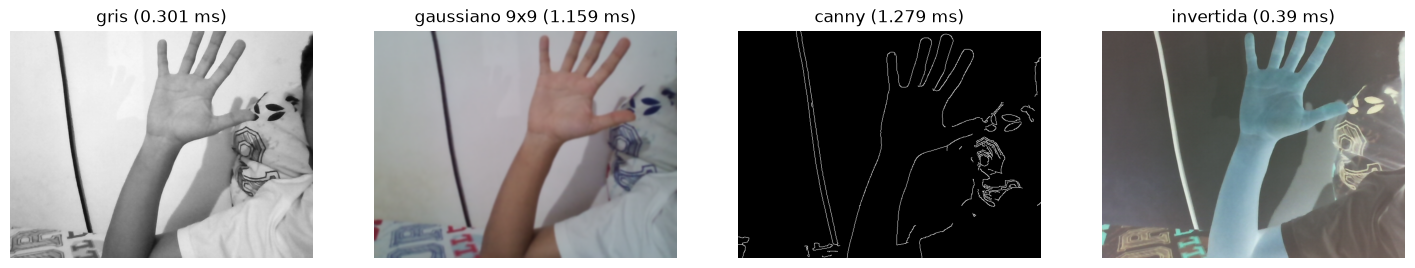

In [12]:
fig, ax = plt.subplots(1, 4, figsize=(18, 4))
for a, (nombre, img) in zip(ax, muestras.items()):
    if img.ndim == 2:
        a.imshow(img, cmap='gray')
    else:
        a.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    a.set_title(f"{nombre} ({res_ops[nombre]['ms_operacion']} ms)")
    a.axis('off')
plt.savefig('resultados/4_4_operaciones.png', bbox_inches='tight')
plt.show()

- Todas quedaron entre 28 y 30 fps, o sea igual de fluidas. Las operaciones tardan entre 0.3 y 1.3 ms y entre frame y frame hay ~33 ms, sobra tiempo.
- La más pesada fue Canny (1.28 ms), después el gaussiano (1.16 ms). Gris e invertida casi no cuestan.
- En detalle: el gris mantiene todo menos el color; el gaussiano borra detalles (se ve desenfocado); Canny deja solo los contornos de la mano y del cojín, que es lo más útil si quiero detectar formas; la invertida no aporta mucho, solo se ve raro.
- La invertida tiene menos frames porque le di q más rápido.

## 4.5 Guardar una captura con s

Ojo: en la guía el `if cv2.waitKey(1)... == ord('s')` se agrega aparte del de la q, o sea se llama waitKey **dos veces** por ciclo y a veces la tecla la "consume" el primero y el otro no la ve. Por eso leo la tecla una sola vez y la guardo en una variable.

**s para guardar, q para salir.**

guardada resultados/captura_1.jpg
guardada resultados/captura_2.jpg
guardada resultados/captura_3.jpg
guardada resultados/captura_4.jpg
guardada resultados/captura_5.jpg
guardada resultados/captura_6.jpg
guardada resultados/captura_7.jpg
guardada resultados/captura_8.jpg
guardada resultados/captura_9.jpg
guardada resultados/captura_10.jpg
guardada resultados/captura_11.jpg
guardada resultados/captura_12.jpg
guardada resultados/captura_13.jpg
¿existe captura.jpg? True
tamaño: (480, 640, 3) | peso: 45 KB


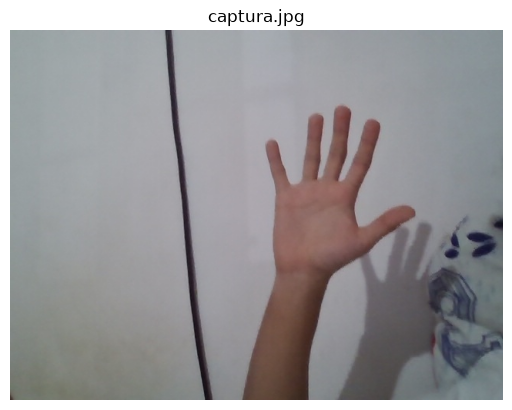

In [13]:
cap, fuente = abrir_camara()
guardadas = []
n = 0
t0 = time.time()
while True:
    ret, frame = cap.read()
    if not ret:
        break
    cv2.imshow('frame', frame)
    n += 1
    k = (cv2.waitKey(1) & 0xFF)
    if k == ord('s'):
        cv2.imwrite('resultados/captura.jpg', frame)                 # la de la guía (se sobreescribe)
        nombre = f'resultados/captura_{len(guardadas) + 1}.jpg'     # y otra numerada para no perderla
        cv2.imwrite(nombre, frame)
        guardadas.append(nombre)
        print('guardada', nombre)
    if k == ord('q') or time.time() - t0 > LIMITE_SEG:
        break
cap.release()
cerrar_ventanas()

print('¿existe captura.jpg?', os.path.exists('resultados/captura.jpg'))
if os.path.exists('resultados/captura.jpg'):
    img = cv2.imread('resultados/captura.jpg')
    print('tamaño:', img.shape, '| peso:', os.path.getsize('resultados/captura.jpg') // 1024, 'KB')
    registrar('4_5_captura', {'archivos': guardadas, 'shape': img.shape,
                              'kb': os.path.getsize('resultados/captura.jpg') // 1024})
    ver(img, 'captura.jpg')

Salieron 13 capturas. Como el ciclo va a 30 vueltas por segundo, si la s se queda presionada un momento guarda una en cada vuelta. `captura.jpg` queda con la última porque se sobreescribe, por eso también guardé las numeradas.

## 4.6 Grabar el flujo con VideoWriter

Tal cual la guía (XVID en .mp4 a 25 fps). Graba unos segundos, **q para parar**. También guardo los primeros 30 frames en memoria para probar otros códecs después.

In [14]:
cap, fuente = abrir_camara()

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

writer = cv2.VideoWriter(
    'resultados/student_capture.mp4',
    cv2.VideoWriter_fourcc(*'XVID'),
    25,
    (width, height)
)
print('writer abierto:', writer.isOpened())

buffer = []
n = 0
t0 = time.time()
while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Escribir cada frame en el archivo
    writer.write(frame)
    if len(buffer) < 30:
        buffer.append(frame.copy())

    # Mostrar el flujo
    cv2.imshow('frame', frame)
    n += 1

    if (cv2.waitKey(1) & 0xFF) == ord('q') or time.time() - t0 > 8:
        break

t_real = time.time() - t0
cap.release()
writer.release()
cerrar_ventanas()

writer abierto: True


In [15]:
def info_video(ruta):
    c = cv2.VideoCapture(ruta)
    if not c.isOpened():
        return {'abre': False}
    k = 0
    while c.read()[0]:
        k += 1
    cc = int(c.get(cv2.CAP_PROP_FOURCC))
    d = {'abre': True, 'frames_leidos': k, 'fps_archivo': c.get(cv2.CAP_PROP_FPS),
         'fourcc_leido': ''.join(chr((cc >> 8 * i) & 0xFF) for i in range(4)),
         'kb': os.path.getsize(ruta) // 1024}
    c.release()
    return d

iv = info_video('resultados/student_capture.mp4')
print(iv)
fps_reales = n / t_real
print(f'se grabaron {n} frames en {t_real:.1f} s reales -> la cámara iba a {fps_reales:.1f} fps')
print(f'el archivo dice 25 fps, entonces dura {n/25:.1f} s (debería durar {t_real:.1f} s)')
registrar('4_6_grabacion', {'fuente': fuente, 'writer_abierto': True, 'info': iv, 'frames': n,
                            'segundos_reales': round(t_real, 2), 'fps_reales': round(fps_reales, 1),
                            'duracion_archivo_s': round(n / 25, 2)})

{'abre': True, 'frames_leidos': 127, 'fps_archivo': 25.0, 'fourcc_leido': 'FMP4', 'kb': 422}
se grabaron 127 frames en 4.4 s reales -> la cámara iba a 29.2 fps
el archivo dice 25 fps, entonces dura 5.1 s (debería durar 4.4 s)


La cámara iba a ~29 fps pero el archivo quedó diciendo 25 (porque así se lo puse al writer), entonces 4.4 s grabados se reproducen en 5.1 s, el video se ve un poquito en cámara lenta. El 25 no es algo que la cámara diga, es lo que yo le digo al archivo.

También el fourcc leído es FMP4 y no XVID: XVID no va en contenedor mp4, OpenCV lo cambió solo a mp4v.

Pruebo varios códecs con los mismos 30 frames, a ver cuáles funcionan en mi equipo:

In [16]:
os.makedirs('resultados/codecs', exist_ok=True)
h, w = buffer[0].shape[:2]
res_codecs = []
for fcc, ext in [('XVID', '.mp4'), ('XVID', '.avi'), ('mp4v', '.mp4'), ('MJPG', '.avi'), ('avc1', '.mp4')]:
    ruta = f'resultados/codecs/prueba_{fcc}{ext}'
    wr = cv2.VideoWriter(ruta, cv2.VideoWriter_fourcc(*fcc), 25, (w, h))
    abierto = wr.isOpened()
    for fr in buffer:
        wr.write(fr)
    wr.release()
    fila = {'fourcc': fcc, 'ext': ext, 'writer_abierto': abierto}
    fila.update(info_video(ruta) if os.path.exists(ruta) else {'abre': False})
    res_codecs.append(fila)
    print(fila)
registrar('4_6_codecs', res_codecs)

{'fourcc': 'XVID', 'ext': '.mp4', 'writer_abierto': True, 'abre': True, 'frames_leidos': 30, 'fps_archivo': 25.0, 'fourcc_leido': 'FMP4', 'kb': 90}
{'fourcc': 'XVID', 'ext': '.avi', 'writer_abierto': True, 'abre': True, 'frames_leidos': 30, 'fps_archivo': 25.0, 'fourcc_leido': 'FMP4', 'kb': 96}
{'fourcc': 'mp4v', 'ext': '.mp4', 'writer_abierto': True, 'abre': True, 'frames_leidos': 30, 'fps_archivo': 25.0, 'fourcc_leido': 'FMP4', 'kb': 90}
{'fourcc': 'MJPG', 'ext': '.avi', 'writer_abierto': True, 'abre': True, 'frames_leidos': 30, 'fps_archivo': 25.0, 'fourcc_leido': 'MJPG', 'kb': 276}
{'fourcc': 'avc1', 'ext': '.mp4', 'writer_abierto': True, 'abre': True, 'frames_leidos': 30, 'fps_archivo': 25.0, 'fourcc_leido': 'h264', 'kb': 509}


En Windows funcionaron todos, hasta avc1 (H.264), que da el archivo más pesado en esta prueba. XVID en .mp4 pesa exactamente lo mismo que mp4v (90 KB) porque en realidad es lo mismo. MJPG pesa 3 veces más porque comprime cada frame como un JPG aparte.

Dos errores típicos: tamaño distinto al declarado, y escribir frames en gris sin avisarle al writer:

In [17]:
# 1) le digo un tamaño y le mando otro
wr = cv2.VideoWriter('resultados/codecs/tam_malo.mp4', cv2.VideoWriter_fourcc(*'mp4v'), 25, (w, h))
for fr in buffer:
    wr.write(cv2.resize(fr, (w // 2, h // 2)))
wr.release()
malo1 = info_video('resultados/codecs/tam_malo.mp4')

# 2) frames de 1 canal con isColor=True (el valor por defecto)
wr = cv2.VideoWriter('resultados/codecs/gris_malo.mp4', cv2.VideoWriter_fourcc(*'mp4v'), 25, (w, h))
for fr in buffer:
    wr.write(cv2.cvtColor(fr, cv2.COLOR_BGR2GRAY))
wr.release()
malo2 = info_video('resultados/codecs/gris_malo.mp4')

# 2b) arreglado con isColor=False
wr = cv2.VideoWriter('resultados/codecs/gris_bien.mp4', cv2.VideoWriter_fourcc(*'mp4v'), 25, (w, h), isColor=False)
for fr in buffer:
    wr.write(cv2.cvtColor(fr, cv2.COLOR_BGR2GRAY))
wr.release()
bien2 = info_video('resultados/codecs/gris_bien.mp4')

print('tamaño equivocado:', malo1)
print('gris sin isColor=False:', malo2)
print('gris con isColor=False:', bien2)
registrar('4_6_errores', {'tam_malo': malo1, 'gris_malo': malo2, 'gris_bien': bien2})

tamaño equivocado: {'abre': False}
gris sin isColor=False: {'abre': False}
gris con isColor=False: {'abre': True, 'frames_leidos': 30, 'fps_archivo': 25.0, 'fourcc_leido': 'FMP4', 'kb': 85}


Los dos primeros no dan error en Python, simplemente el archivo queda vacío (257 bytes) y no se puede abrir. Eso es peligroso porque uno cree que grabó. Con `isColor=False` el de gris sí funciona.

## 4.8 Reto - dos ventanas (original y bordes)

**q para salir.** Guardo cómo se veían las dos ventanas al final.

después de release, isOpened = False


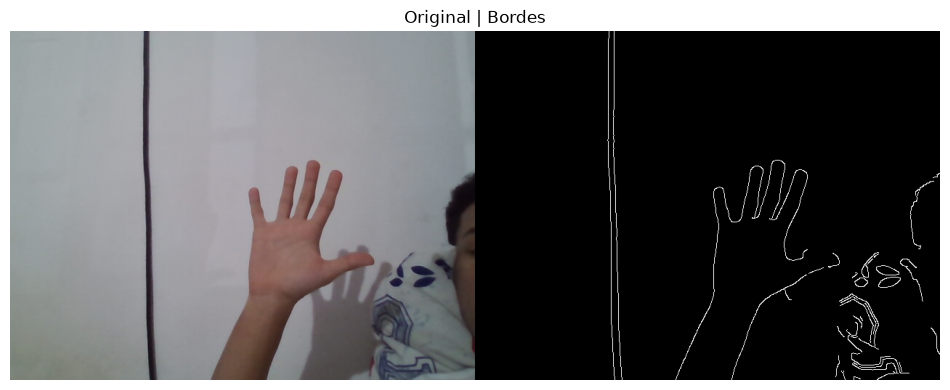

In [18]:
cap, fuente = abrir_camara()
n = 0
t0 = time.time()
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 100, 200)

    cv2.imshow('Original', frame)
    cv2.imshow('Bordes', edges)
    n += 1

    if (cv2.waitKey(1) & 0xFF) == ord('q') or time.time() - t0 > LIMITE_SEG:
        break

cap.release()
cerrar_ventanas()
print('después de release, isOpened =', cap.isOpened())

dos = cv2.hconcat([frame, cv2.cvtColor(edges, cv2.COLOR_GRAY2BGR)])
cv2.imwrite('resultados/4_8_dos_ventanas.jpg', dos)
registrar('4_8_reto', {'frames': n, 'fps': round(n / (time.time() - t0), 1)})
ver(dos, 'Original | Bordes', ancho=12)

Con dos ventanas bajó un poco, a 26 fps, porque cada vuelta hay que dibujar dos imágenes. Al final `isOpened` quedó en False, la cámara quedó liberada.

## 5. Actividad integradora - miniaplicación

El mismo código está en `camara_app.py` para correrlo desde la terminal (`python camara_app.py`).

Teclas: **1** gris, **2** Canny, **3** desenfoque, **4** umbral adaptativo, **s** captura, **r** empezar/parar grabación, **q** salir.

Decisiones que tomé:
- dos ventanas: `Original` (con resolución, fps, modo y un punto rojo cuando graba) y `Procesado`
- el teclado se lee una sola vez por ciclo (por lo de la 4.5)
- los FPS para grabar los mido al arrancar en vez de poner 25 fijo (por lo de la 4.6)
- como gris, Canny y umbral son de 1 canal, los paso a BGR antes de escribirlos al video
- códec mp4v en .mp4 y si no abre prueba XVID y MJPG en .avi
- todo lo de liberar va en un `finally`, así se libera aunque haya un error

In [19]:
# Miniaplicación de la actividad integradora (Lab 30 - cámara)
#
# Teclas (con la ventana seleccionada):
#   1 gris | 2 Canny | 3 desenfoque | 4 umbral adaptativo
#   s guardar captura | r empezar/parar grabación | q salir
#
# Uso desde terminal:  python camara_app.py            (cámara 0)
#                      python camara_app.py 1          (otra cámara)
#
# Hay que darle clic a la ventana para que reciba las teclas.

import os
import sys
import time

import cv2

MODOS = {ord('1'): 'gris', ord('2'): 'canny', ord('3'): 'desenfoque', ord('4'): 'umbral'}

# orden de códecs a probar para grabar: (fourcc, extensión)
CODECS = [('mp4v', '.mp4'), ('XVID', '.avi'), ('MJPG', '.avi')]


def procesar(frame, modo):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    if modo == 'gris':
        return gray
    if modo == 'canny':
        # un poquito de blur antes para que no salga tanto ruido del sensor
        return cv2.Canny(cv2.GaussianBlur(gray, (5, 5), 0), 50, 150)
    if modo == 'desenfoque':
        return cv2.GaussianBlur(frame, (15, 15), 0)
    if modo == 'umbral':
        return cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                     cv2.THRESH_BINARY, 11, 2)
    return frame


def a_bgr(img):
    # VideoWriter y hconcat necesitan 3 canales
    return img if img.ndim == 3 else cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)


def abrir_writer(base, fps, tam):
    for fcc, ext in CODECS:
        ruta = base + ext
        w = cv2.VideoWriter(ruta, cv2.VideoWriter_fourcc(*fcc), fps, tam)
        if w.isOpened():
            return w, ruta, fcc
        w.release()
    return None, None, None


def app(fuente=0, limite_seg=None, carpeta='resultados/app'):
    os.makedirs(carpeta, exist_ok=True)
    eventos = []

    def log(msg):
        t = time.strftime('%H:%M:%S')
        eventos.append(f'{t} {msg}')
        print(f'[{t}] {msg}')

    # 1. conectar y verificar
    cap = cv2.VideoCapture(fuente)
    if not cap.isOpened():
        log(f'no se pudo abrir la cámara {fuente} (revisar permisos o si otro programa la está usando)')
        return {'error': 'sin cámara', 'eventos': eventos}
    ok, frame = cap.read()
    if not ok:
        log('la cámara abrió pero no entrega frames')
        cap.release()
        return {'error': 'sin frames', 'eventos': eventos}

    # 2. resolución (la saco del frame, que es lo que de verdad llega)
    h, w = frame.shape[:2]
    log(f'fuente {fuente} conectada, resolución {w}x{h}, backend {cap.getBackendName()}')

    # FPS: la propiedad muchas veces sale 0 o 30 fijo en webcams, así que también lo mido
    fps_prop = cap.get(cv2.CAP_PROP_FPS)
    t0 = time.time()
    for _ in range(20):
        cap.read()
    fps_med = 20 / (time.time() - t0)
    if 5 <= fps_med <= 60:
        fps_grab = fps_med
    else:
        fps_grab = fps_prop if fps_prop > 0 else 20
    log(f'FPS propiedad={fps_prop:.1f}, medidos={fps_med:.1f}, para grabar uso {fps_grab:.1f}')

    modo = 'gris'
    writer, ruta_video, frames_rec = None, None, 0
    capturas, videos = [], []
    n = 0
    fps_vis = 0.0
    t_ant = time.time()
    t_ini = time.time()

    try:
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                log('read() devolvió False (se desconectó la cámara)')
                break
            n += 1

            procesado = procesar(frame, modo)

            if writer is not None:
                writer.write(a_bgr(procesado))
                frames_rec += 1

            # fps de la visualización (suavizado)
            ahora = time.time()
            fps_inst = 1 / max(ahora - t_ant, 1e-6)
            fps_vis = fps_inst if fps_vis == 0 else 0.9 * fps_vis + 0.1 * fps_inst
            t_ant = ahora

            vista = frame.copy()
            cv2.putText(vista, f'{w}x{h}  {fps_vis:4.1f} fps  modo: {modo}', (10, 25),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)
            cv2.putText(vista, '1 gris 2 canny 3 blur 4 umbral | s foto | r grabar | q salir',
                        (10, h - 12), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 255), 1)
            if writer is not None:
                cv2.circle(vista, (w - 25, 22), 9, (0, 0, 255), -1)
                cv2.putText(vista, 'REC', (w - 75, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)

            cv2.imshow('Original', vista)
            cv2.imshow('Procesado', procesado)
            k = cv2.waitKey(1) & 0xFF   # una sola lectura del teclado por ciclo

            if k == ord('q'):
                log('q presionada, saliendo')
                break
            elif k in MODOS:
                modo = MODOS[k]
                log(f'modo -> {modo}')
            elif k == ord('s'):
                i = len(capturas) + 1
                r1 = f'{carpeta}/captura_{i}_original.jpg'
                r2 = f'{carpeta}/captura_{i}_{modo}.jpg'
                r3 = f'{carpeta}/pantalla_{i}.jpg'   # como se veían las dos ventanas
                cv2.imwrite(r1, frame)
                cv2.imwrite(r2, procesado)
                cv2.imwrite(r3, cv2.hconcat([vista, a_bgr(procesado)]))
                capturas.append({'original': r1, 'procesada': r2, 'pantalla': r3, 'modo': modo})
                log(f'captura guardada: {r1}, {r2}')
            elif k == ord('r'):
                if writer is None:
                    base = f'{carpeta}/grabacion_{len(videos) + 1}'
                    writer, ruta_video, fcc = abrir_writer(base, fps_grab, (w, h))
                    if writer is None:
                        log('no se pudo abrir ningún códec para grabar')
                    else:
                        frames_rec = 0
                        t_rec = time.time()
                        log(f'grabando en {ruta_video} con {fcc} a {fps_grab:.1f} fps')
                else:
                    writer.release()
                    dur = time.time() - t_rec
                    videos.append({'ruta': ruta_video, 'frames': frames_rec,
                                   'duracion_real_s': round(dur, 2),
                                   'duracion_archivo_s': round(frames_rec / fps_grab, 2)})
                    log(f'grabación detenida: {frames_rec} frames en {dur:.1f} s')
                    writer = None

            if limite_seg and time.time() - t_ini > limite_seg:
                log(f'se alcanzó el límite de {limite_seg} s')
                break
    finally:
        # 7. liberar todo pase lo que pase
        if writer is not None:
            writer.release()
            dur = time.time() - t_rec
            videos.append({'ruta': ruta_video, 'frames': frames_rec,
                           'duracion_real_s': round(dur, 2),
                           'duracion_archivo_s': round(frames_rec / fps_grab, 2)})
            log('se cerró la grabación que seguía abierta')
        cap.release()
        cv2.destroyAllWindows()
        for _ in range(5):
            cv2.waitKey(1)   # a veces las ventanas se quedan pegadas si no se hace esto
        log(f'recursos liberados (cap.isOpened() = {cap.isOpened()})')

    return {'fuente': str(fuente), 'resolucion': [w, h], 'fps_propiedad': fps_prop,
            'fps_medidos': round(fps_med, 2), 'fps_grabacion': round(fps_grab, 2),
            'frames_mostrados': n, 'fps_visualizacion': round(fps_vis, 1),
            'capturas': capturas, 'videos': videos, 'eventos': eventos}

In [20]:
resumen = app(fuente=INDICE_CAMARA, limite_seg=90)
for v in resumen['videos']:
    v.update(info_video(v['ruta']))
registrar('5_integradora', resumen)
{k: v for k, v in resumen.items() if k != 'eventos'}

[22:01:47] fuente 0 conectada, resolución 640x480, backend MSMF
[22:01:47] FPS propiedad=30.0, medidos=29.7, para grabar uso 29.7
[22:01:52] modo -> canny
[22:01:53] modo -> desenfoque
[22:01:54] modo -> umbral
[22:01:56] captura guardada: resultados/app/captura_1_original.jpg, resultados/app/captura_1_umbral.jpg
[22:01:57] captura guardada: resultados/app/captura_2_original.jpg, resultados/app/captura_2_umbral.jpg
[22:01:58] captura guardada: resultados/app/captura_3_original.jpg, resultados/app/captura_3_umbral.jpg
[22:02:00] grabando en resultados/app/grabacion_1.mp4 con mp4v a 29.7 fps
[22:02:04] grabación detenida: 144 frames en 4.8 s
[22:02:06] captura guardada: resultados/app/captura_4_original.jpg, resultados/app/captura_4_umbral.jpg
[22:02:06] q presionada, saliendo
[22:02:07] recursos liberados (cap.isOpened() = False)


{'fuente': '0',
 'resolucion': [640, 480],
 'fps_propiedad': 30.0,
 'fps_medidos': 29.73,
 'fps_grabacion': 29.73,
 'frames_mostrados': 569,
 'fps_visualizacion': 55.6,
 'capturas': [{'original': 'resultados/app/captura_1_original.jpg',
   'procesada': 'resultados/app/captura_1_umbral.jpg',
   'pantalla': 'resultados/app/pantalla_1.jpg',
   'modo': 'umbral'},
  {'original': 'resultados/app/captura_2_original.jpg',
   'procesada': 'resultados/app/captura_2_umbral.jpg',
   'pantalla': 'resultados/app/pantalla_2.jpg',
   'modo': 'umbral'},
  {'original': 'resultados/app/captura_3_original.jpg',
   'procesada': 'resultados/app/captura_3_umbral.jpg',
   'pantalla': 'resultados/app/pantalla_3.jpg',
   'modo': 'umbral'},
  {'original': 'resultados/app/captura_4_original.jpg',
   'procesada': 'resultados/app/captura_4_umbral.jpg',
   'pantalla': 'resultados/app/pantalla_4.jpg',
   'modo': 'umbral'}],
 'videos': [{'ruta': 'resultados/app/grabacion_1.mp4',
   'frames': 144,
   'duracion_real_s':

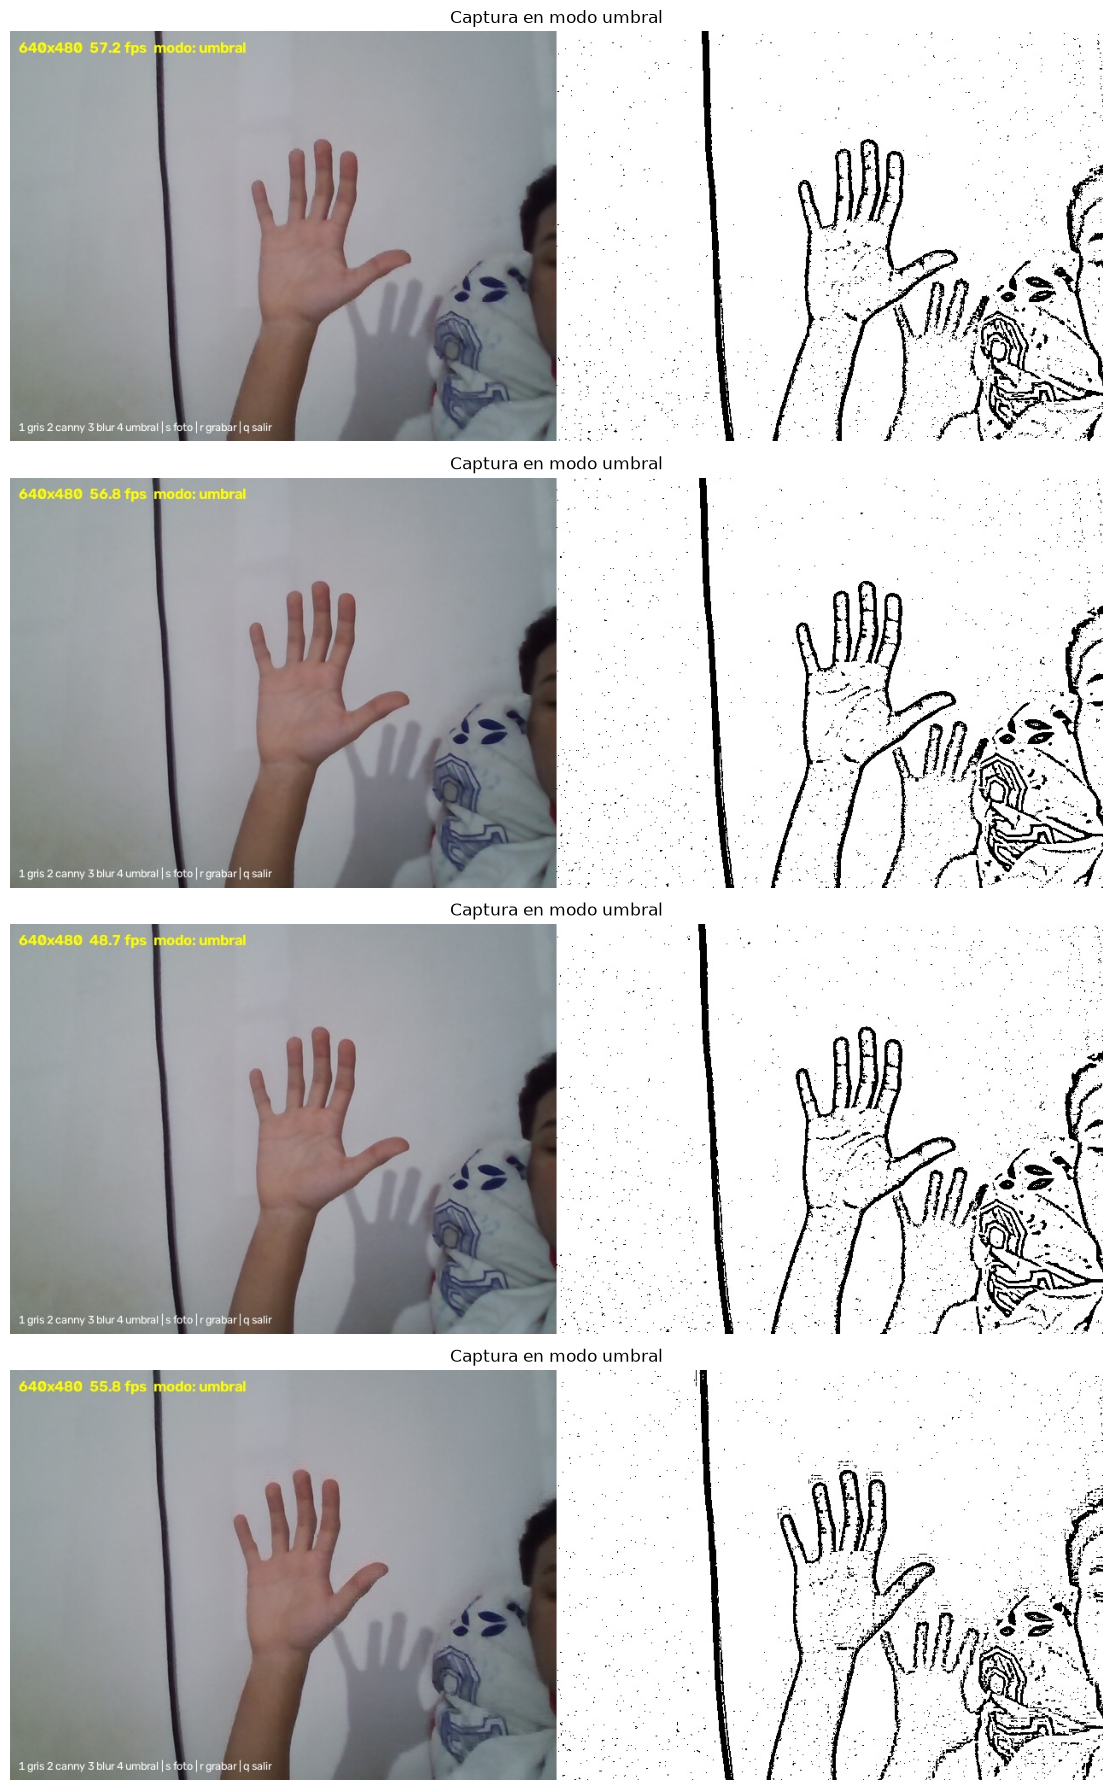

{'ruta': 'resultados/app/grabacion_1.mp4', 'frames': 144, 'duracion_real_s': 4.81, 'duracion_archivo_s': 4.84, 'abre': True, 'frames_leidos': 144, 'fps_archivo': 29.727, 'fourcc_leido': 'FMP4', 'kb': 7347}


In [21]:
caps = resumen['capturas']
if caps:
    fig, ax = plt.subplots(len(caps), 1, figsize=(14, 4.5 * len(caps)))
    ax = np.atleast_1d(ax)
    for a, c in zip(ax, caps):
        a.imshow(cv2.cvtColor(cv2.imread(c['pantalla']), cv2.COLOR_BGR2RGB))
        a.set_title(f"Captura en modo {c['modo']}")
        a.axis('off')
    plt.tight_layout()
    plt.savefig('resultados/5_capturas_app.png', bbox_inches='tight')
    plt.show()
else:
    print('no se tomó ninguna captura')

for v in resumen['videos']:
    print(v)

Lo que pasó según el registro: arrancó en gris, pasé por Canny, desenfoque y umbral, tomé 4 capturas en modo umbral, grabé ~5 s y salí con q.

- El video quedó con 144 frames a 29.7 fps: dura 4.84 s y la grabación real fue de 4.81 s. Como usé los fps medidos, ahora sí coincide (en la 4.6 con 25 fijo no).
- El umbral adaptativo marca muy bien la mano y los dedos, pero la pared sale con puntitos (ruido del sensor), quizás con un blur antes mejora.
- Los fps que muestra en pantalla (~56) salen más altos que los de la cámara (~30). Creo que es porque MSMF a veces entrega frames que ya tenía en memoria y esas vueltas duran casi nada, entonces el promedio se infla. Los 29.7 medidos al inicio son los reales.

## 6. Resumen de todo lo medido

In [22]:
print(json.dumps(datos, indent=1, ensure_ascii=False, default=str)[:4000])
print()
print('Archivos generados en resultados/:')
for f in sorted(glob.glob('resultados/**/*', recursive=True)):
    if os.path.isfile(f):
        print(f'  {f}  ({os.path.getsize(f)//1024} KB)')

{
 "equipo": {
  "so": "Windows 11",
  "python": "3.12.10",
  "opencv": "5.0.0",
  "hay_gui": true,
  "backends_camara": [
   "GSTREAMER",
   "MSMF",
   "DSHOW",
   "FFMPEG",
   "UEYE",
   "OBSENSOR"
  ]
 },
 "4_1_indices": [
  {
   "indice": 0,
   "isOpened": true,
   "read": true,
   "backend": "MSMF",
   "shape": [
    480,
    640,
    3
   ]
  },
  {
   "indice": 1,
   "isOpened": false,
   "read": false,
   "backend": null,
   "shape": null
  },
  {
   "indice": 2,
   "isOpened": false,
   "read": false,
   "backend": null,
   "shape": null
  },
  {
   "indice": 3,
   "isOpened": false,
   "read": false,
   "backend": null,
   "shape": null
  }
 ],
 "fuente": "camara 0",
 "4_3_gris": {
  "fuente": "camara 0",
  "resolucion": [
   640,
   480
  ],
  "frames": 554,
  "segundos": 18.55,
  "fps": 29.9
 },
 "4_4_operaciones": {
  "gris": {
   "frames": 173,
   "fps": 28.8,
   "ms_operacion": 0.301
  },
  "gaussiano 9x9": {
   "frames": 183,
   "fps": 30.3,
   "ms_operacion": 1.159
  }

Todo quedó en `resultados/`: capturas, videos y `datos_lab30.json` con las medidas. Las respuestas a las preguntas están en el informe.